# Telecom Customer Churn Prediction

An end-to-end machine-learning project that identifies customers at risk of leaving a telecom service. The notebook uses a leakage-safe scikit-learn pipeline, cross-validation on the original training rows, and an untouched test set for final evaluation.

**Author:** Mohammed Altamash Khan

## 1. Imports and configuration

In [1]:
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Load and understand the dataset

In [2]:
DATA_PATH = Path('../data/Telco-Customer-Churn.csv')
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()
print('\nDuplicate rows:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Data cleaning

`TotalCharges` contains 11 blank strings belonging to new customers with zero tenure. They are converted to numeric and filled with zero. `customerID` is removed because it is only an identifier.

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Missing TotalCharges:', df['TotalCharges'].isna().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop(columns='customerID')
print('Remaining missing values:', int(df.isna().sum().sum()))

Missing TotalCharges: 11
Remaining missing values: 0


## 4. Exploratory data analysis

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


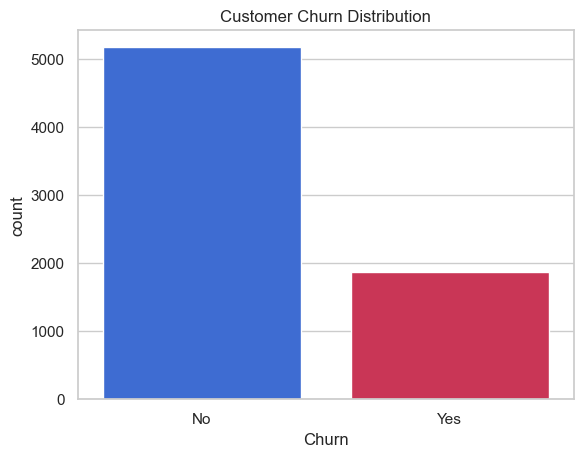

In [5]:
churn_rate = df['Churn'].value_counts(normalize=True).mul(100)
print(churn_rate.round(2))
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2563eb', '#e11d48'], legend=False)
plt.title('Customer Churn Distribution')
plt.show()

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


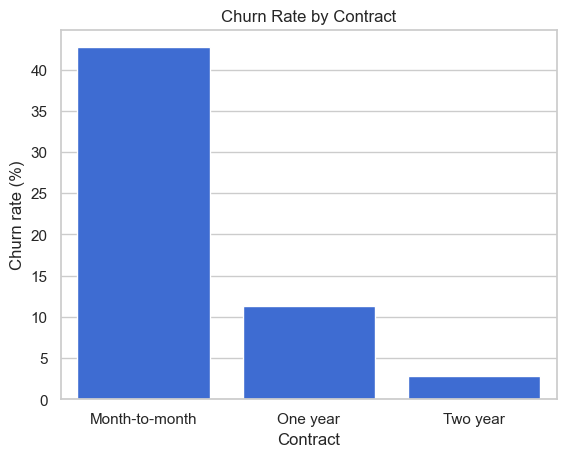

In [6]:
contract_rate = df.groupby('Contract')['Churn'].apply(lambda s: s.eq('Yes').mean() * 100).sort_values(ascending=False)
print(contract_rate.round(1))
sns.barplot(x=contract_rate.index, y=contract_rate.values, color='#2563eb')
plt.ylabel('Churn rate (%)'); plt.title('Churn Rate by Contract'); plt.show()

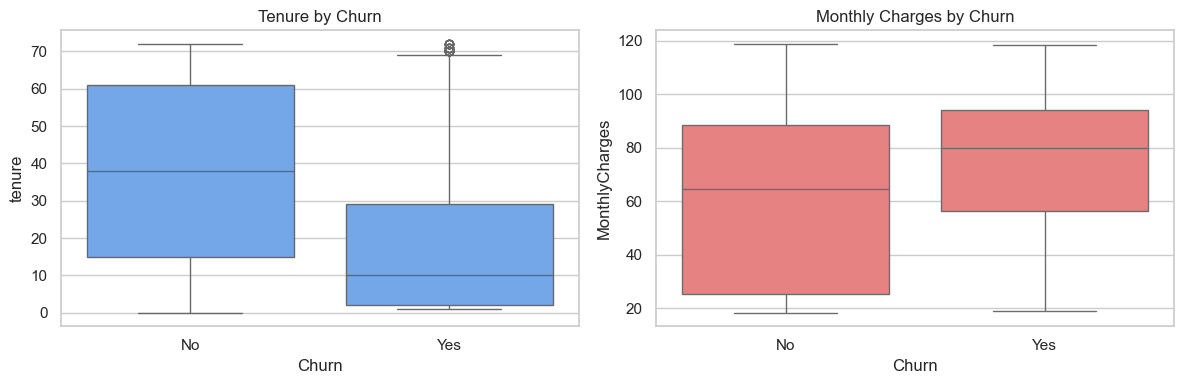

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], color='#60a5fa')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], color='#f87171')
axes[0].set_title('Tenure by Churn'); axes[1].set_title('Monthly Charges by Churn')
plt.tight_layout(); plt.show()

### EDA findings

- Month-to-month customers have the highest churn rate.
- Churners generally have shorter tenure.
- Higher monthly charges are associated with churn.
- These are associations in this sample; they do not prove causation.

## 5. Feature selection and train-test split

The deployment model uses exactly the eight fields collected by the web app. This prevents hidden default values from silently influencing predictions.

In [8]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport']
X = df[features].copy()
y = df['Churn'].map({'No': 0, 'Yes': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print('Training:', X_train.shape, 'Test:', X_test.shape)
print(y_train.value_counts(normalize=True).round(3))

Training: (5634, 8) Test: (1409, 8)
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


## 6. Leakage-safe preprocessing and model

Preprocessing is inside the pipeline. Scaling and encoding are therefore fitted separately inside each cross-validation fold. Class imbalance is handled with `class_weight="balanced"`; no duplicated rows are created.

In [9]:
numeric = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical = [c for c in features if c not in numeric]
preprocess = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical),
])
pipeline = Pipeline([('preprocess', preprocess), ('model', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE))])
pipeline

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 7. Hyperparameter tuning

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipeline, {'model__C': [0.01, 0.1, 1, 10]}, scoring='f1', cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)
print('Best parameters:', grid.best_params_)
print(f'Best cross-validated F1: {grid.best_score_:.3f}')

Best parameters: {'model__C': 0.01}
Best cross-validated F1: 0.622


## 8. Final evaluation on untouched test data

In [11]:
final_model = grid.best_estimator_
y_probability = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_probability >= 0.50).astype(int)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print('Precision:', round(precision_score(y_test, y_pred), 3))
print('Recall:', round(recall_score(y_test, y_pred), 3))
print('F1:', round(f1_score(y_test, y_pred), 3))
print('ROC-AUC:', round(roc_auc_score(y_test, y_probability), 3))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409

Accuracy: 0.733
Precision: 0.498
Recall: 0.775
F1: 0.607
ROC-AUC: 0.834


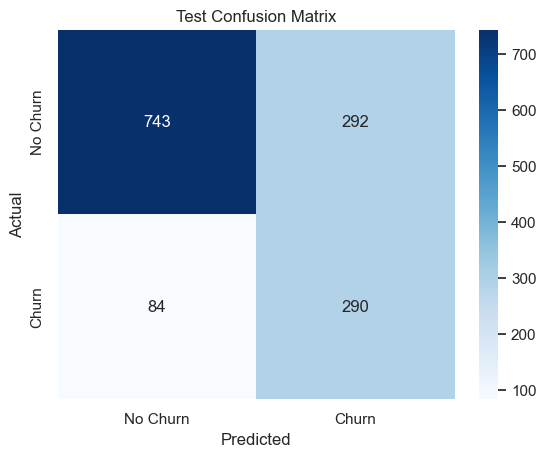

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Test Confusion Matrix'); plt.show()

## 9. Save the complete pipeline

The exported artifact contains preprocessing and the classifier together, eliminating manual one-hot encoding and column-order errors in the Flask app.

In [13]:
ARTIFACT_PATH = Path('../artifacts/churn_pipeline.joblib')
joblib.dump(final_model, ARTIFACT_PATH, compress=3)
print('Saved:', ARTIFACT_PATH)

Saved: ..\artifacts\churn_pipeline.joblib


## 10. Business recommendations

1. Target new, month-to-month customers with onboarding and retention offers.
2. Test annual-contract incentives instead of applying blanket discounts.
3. Investigate why higher-charge and fiber-optic segments show higher churn.
4. Use prediction scores to prioritize outreach, then measure campaign lift.

### Limitations

- This is an IBM sample dataset, not live production data.
- Associations do not establish the causes of churn.
- The model should be monitored and retrained before real operational use.